In [1]:
from pathlib import Path 

import cv2 
import numpy as np
import IPython
from videotools.detectors import FaceDetectorYunet

2024-06-01 20:37:02.226177: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-01 20:37:02.977992: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def draw_faces(image, faces, draw_landmarks):
    for face in faces:
        # バウンディングボックス
        color = (0, 0, 255)
        thickness = 2
        cv2.rectangle(image, (face['x1'], face['y1']), (face['x2'], face['y2']), color, thickness, cv2.LINE_AA)

        if draw_landmarks:
            # ランドマーク（右目、左目、鼻、右口角、左口角）
            landmarks = face['landmarks']
            for landmark in landmarks:
                radius = 5
                thickness = -1
                cv2.circle(image, landmark, radius, color, thickness, cv2.LINE_AA)
            
        # 信頼度
        confidence = face['confidence']
        confidence = "{:.2f}".format(confidence)
        position = (face['x1'], face['y1'] - 10)
        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = 0.5
        thickness = 2
        cv2.putText(image, confidence, position, font, scale, color, thickness, cv2.LINE_AA)

In [3]:
def show_image(image):
    _, ret = cv2.imencode('.jpg', image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)

In [4]:
def show_by_name(name):
    fp = Path('../test_images').joinpath(name)
    img = cv2.imread(str(fp))
    show_image(img)

In [5]:
def show_faces(image, faces, draw_landmarks=True):
    draw_faces(image, faces, draw_landmarks=draw_landmarks)
    show_image(image)

In [6]:
fd = FaceDetectorYunet()

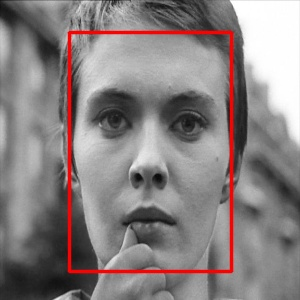

In [8]:
org = cv2.imread('./images/img_1.jpg')
img = cv2.resize(org, (300, 300))
faces = fd.detect(img)
fd.draw_faces(img, faces)
show_image(img)

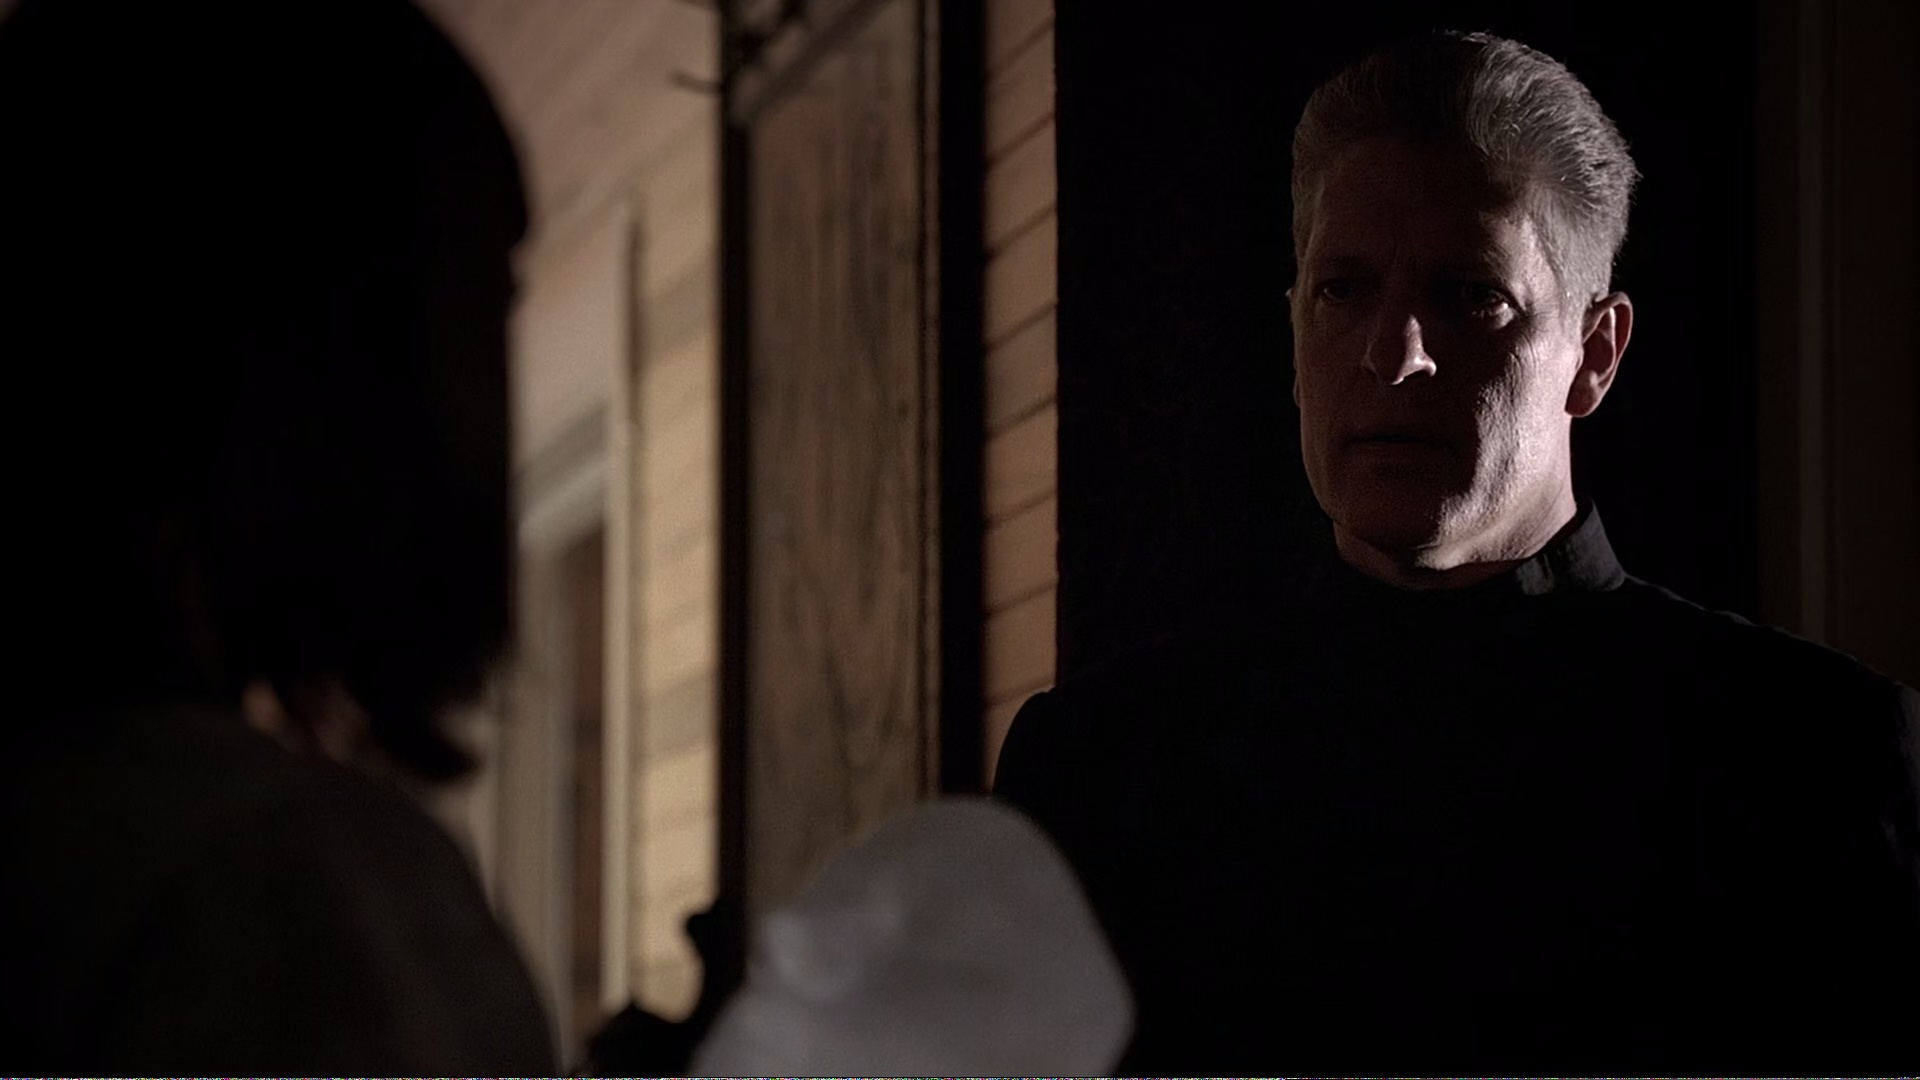

In [23]:
src = '../test_images/Carnivale.S02E11.1080p.WEBRip.10Bit.EAC3.H265-d3g_49632.png'
show_by_name(src)

In [24]:
img = cv2.imread(src)
faces = fd.detect(img)
fd.draw_faces(img, faces)
show_image(img)

TypeError: 'NoneType' object is not iterable